In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('gender_submission.csv')
df1 = pd.read_csv('test.csv')
df2 = pd.read_csv('train.csv')

In [2]:
df

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [3]:
df1

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [4]:
df2

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
df2.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df2.info()
df2.describe()
df2.isnull().sum()
df2['Survived'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,count
Survived,
0,549
1,342


In [7]:
df2['Pclass'].value_counts()


,count
Pclass,
3,491
1,216
2,184


In [8]:
df2['Sex'].value_counts()

,count
Sex,
male,577
female,314


<Axes: xlabel='Age', ylabel='Count'>

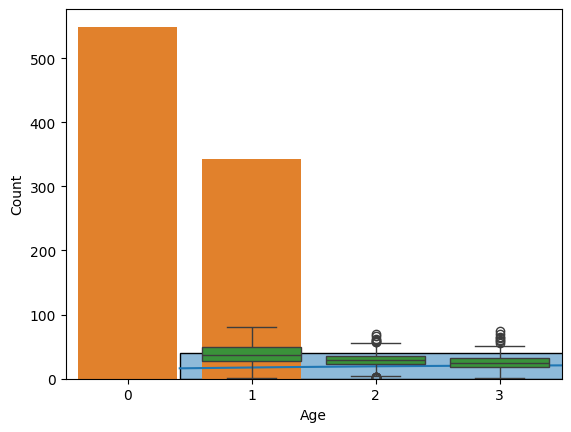

In [9]:
#VISUAL EXPLORATION
#Univariate distribution


sns.histplot(df2['Age'].dropna(), kde=True)
sns.countplot(x='Survived', data=df2)
sns.boxplot(x='Pclass', y='Age', data=df2)


<Axes: xlabel='Pclass', ylabel='Survived'>

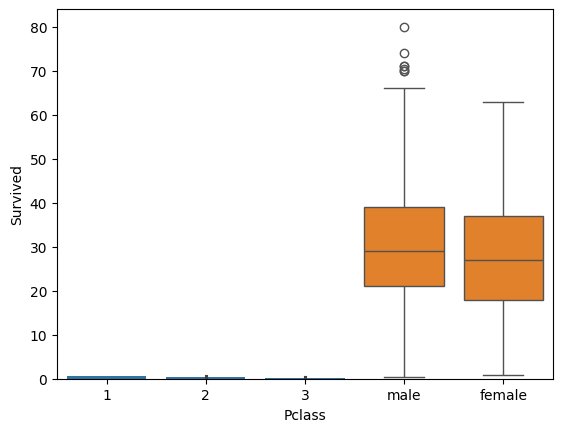

In [13]:
#Bivariate Relationships

sns.barplot(x='Pclass', y='Survived', data=df2)
sns.boxplot(x='Sex', y='Age',data=df2)


<Axes: >

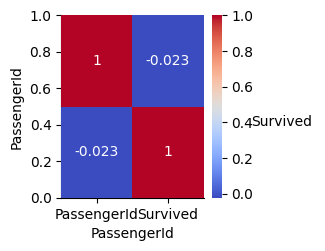

In [21]:

numeric_cols = df.select_dtypes(include=['float64', 'int64'])

# Dropping rows with missing values in these columns for pairplot
sns.pairplot(numeric_cols.dropna(), hue='Survived')

# Heatmap of correlation between numeric variables
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')


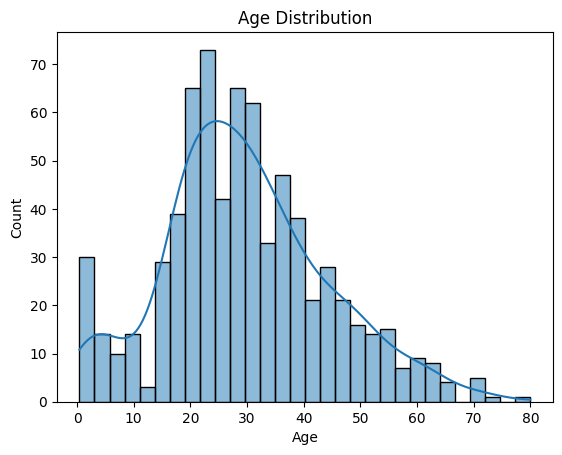

In [22]:
#histogram
#age distribution
sns.histplot(df2['Age'].dropna(), bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

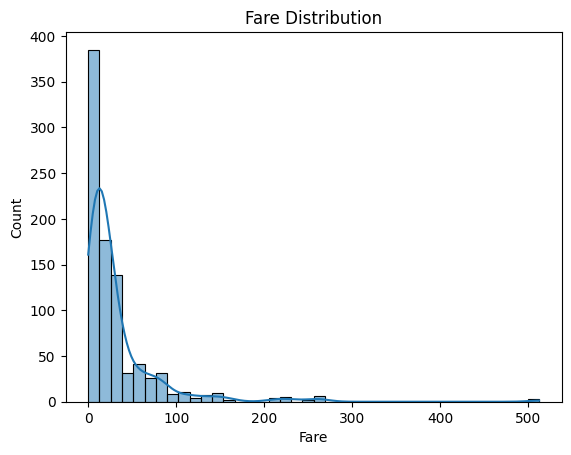

In [24]:
# Fare distribution
sns.histplot(df2['Fare'], bins=40, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

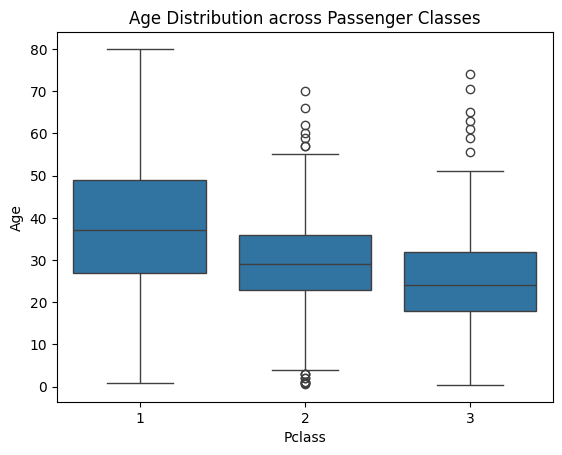

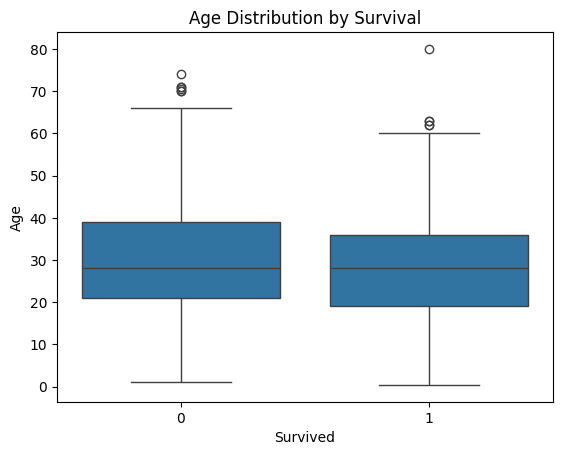

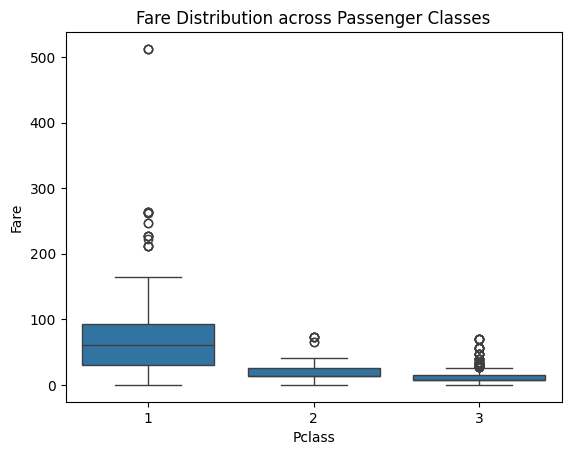

In [25]:
#BOXPLOTS
# Age vs Pclass
sns.boxplot(x='Pclass', y='Age', data=df2)
plt.title("Age Distribution across Passenger Classes")
plt.show()

# Age vs Survived
sns.boxplot(x='Survived', y='Age', data=df2)
plt.title("Age Distribution by Survival")
plt.show()

# Fare vs Pclass
sns.boxplot(x='Pclass', y='Fare', data=df2)
plt.title("Fare Distribution across Passenger Classes")
plt.show()


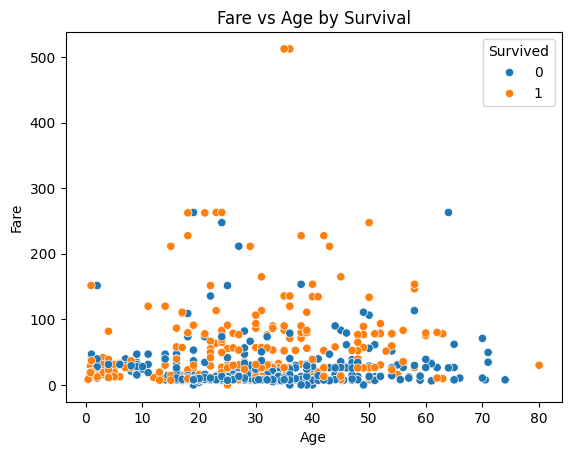

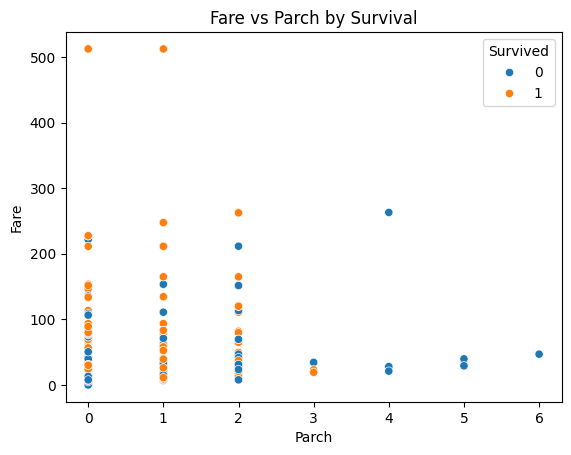

In [26]:
#SCATTERPLOTS
# Age vs Fare colored by Survival
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df2)
plt.title("Fare vs Age by Survival")
plt.show()

# Parch vs Fare
sns.scatterplot(x='Parch', y='Fare', hue='Survived', data=df2)
plt.title("Fare vs Parch by Survival")
plt.show()
